In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
plt.style.use(['science','notebook'])

In [21]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [22]:
# Thresholds for t-stat with 21-1 dof (TiBET dataset, 21 subjects)
t_20dof_95 = 1.725
t_20dof_99 = 2.528

# Thresholds for t-stat with 19-1 dof (DADA dataset, 19 subjects)
t_18dof_95 = 1.734
t_18dof_99 = 2.552

### Read data

In [23]:
channels_X = ["CP6", "C6"]
channels_Y = ["Fz", "FC2"]
info_imbalances_X_to_Y = {}
info_imbalances_Y_to_X = {}
IGs_X_to_Y = {}
errors_X_to_Y = {}
IGs_Y_to_X = {}
errors_Y_to_X = {}

# TiBET parameters
subjects_tibet = (['03CM','04ML','05NK','06AT','07YC','08RD','09NT','10EM','11AD','12AD',
             '13AB','14LS','15AC','16AG','17SM','18NB','19LS','20FC','21AB','22RT','23ST'])
E_tibet = 45
k_tibet = 7
t0_tibet = 50
taus_tibet = np.arange(0,456) # already in ms (here sampling time is 1 ms)

# DADA parameters
subjects_dada = (["001","002","003","004","005","006","007","008","009","010",
             "011","012","013","014","015","016","017","018","019"])
E_dada = 12
k_dada = 20
t0_dada = 0
taus_dada = 4 * np.arange(0,113) # already in ms (here sampling time is 4 ms)

# common parameters
tau_e = 1
alphas = np.linspace(0.,1.5,300)

for channel_X in channels_X:
    for channel_Y in channels_Y:
        info_imbalances_X_to_Y["tibet",channel_X,channel_Y] = np.zeros((len(subjects_tibet),len(taus_tibet),len(alphas)))
        info_imbalances_Y_to_X["tibet",channel_X,channel_Y] = np.zeros((len(subjects_tibet),len(taus_tibet),len(alphas)))
        info_imbalances_X_to_Y["dada",channel_X,channel_Y] = np.zeros((len(subjects_dada),len(taus_dada),len(alphas)))
        info_imbalances_Y_to_X["dada",channel_X,channel_Y] = np.zeros((len(subjects_dada),len(taus_dada),len(alphas)))

        # read tibet pickles
        for i_sub, sub in enumerate(subjects_tibet):
            file_name = f"./tibet_analysis/pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0_tibet}_E{E_tibet}_tauE{tau_e}_k{k_tibet}.p"
            _, info_imbalances_X_to_Y["tibet",channel_X,channel_Y][i_sub], info_imbalances_Y_to_X["tibet",channel_X,channel_Y][i_sub] = (
                pickle.load(open(file_name,"rb"))
            )

        # read dada pickles
        for i_sub, sub in enumerate(subjects_dada):
            file_name = f"./dada_analysis/pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0_dada}_E{E_dada}_tauE{tau_e}_k{k_dada}.p"
            _, info_imbalances_X_to_Y["dada",channel_X,channel_Y][i_sub], info_imbalances_Y_to_X["dada",channel_X,channel_Y][i_sub] = (
                pickle.load(open(file_name,"rb"))
            )

        # compute Imbalance Gains
        for dataset in ["tibet","dada"]:
            IGs_X_to_Y[dataset,channel_X,channel_Y], errors_X_to_Y[dataset,channel_X,channel_Y] = (
                compute_IGs(info_imbalances_X_to_Y[dataset,channel_X,channel_Y])
            )
            IGs_Y_to_X[dataset,channel_X,channel_Y], errors_Y_to_X[dataset,channel_X,channel_Y] = (
                compute_IGs(info_imbalances_Y_to_X[dataset,channel_X,channel_Y])
            )

/tmp/ipykernel_7239/2778808513.py:10: RuntimeWarning: invalid value encountered in divide
  mask_tibet = (IGs_X_to_Y["tibet",channel_X,channel_Y] / errors_X_to_Y["tibet",channel_X,channel_Y]) > t_20dof_99
/tmp/ipykernel_7239/2778808513.py:11: RuntimeWarning: invalid value encountered in divide
  mask_dada = (IGs_X_to_Y["dada",channel_X,channel_Y] / errors_X_to_Y["dada",channel_X,channel_Y]) > t_18dof_99


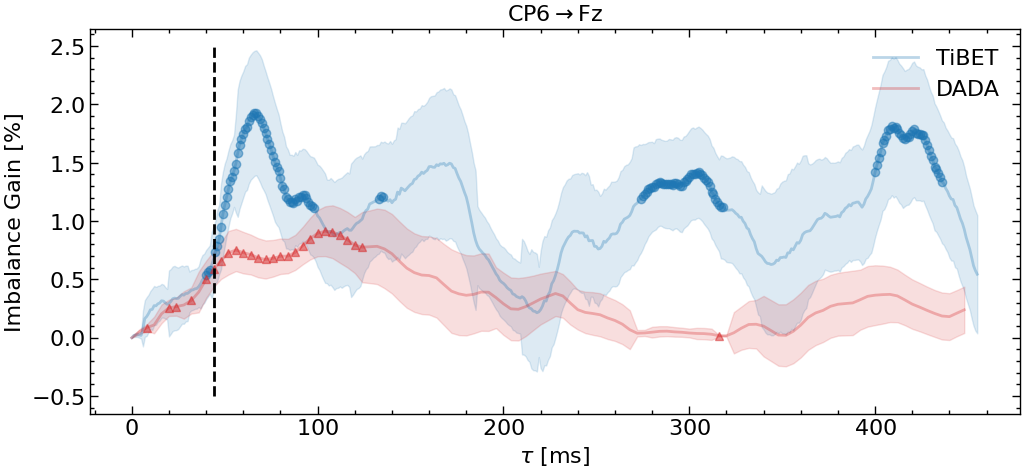

/tmp/ipykernel_7239/2778808513.py:32: RuntimeWarning: invalid value encountered in divide
  mask_tibet = (IGs_Y_to_X["tibet",channel_X,channel_Y] / errors_Y_to_X["tibet",channel_X,channel_Y]) > t_20dof_99
/tmp/ipykernel_7239/2778808513.py:33: RuntimeWarning: invalid value encountered in divide
  mask_dada = (IGs_Y_to_X["dada",channel_X,channel_Y] / errors_Y_to_X["dada",channel_X,channel_Y]) > t_18dof_99


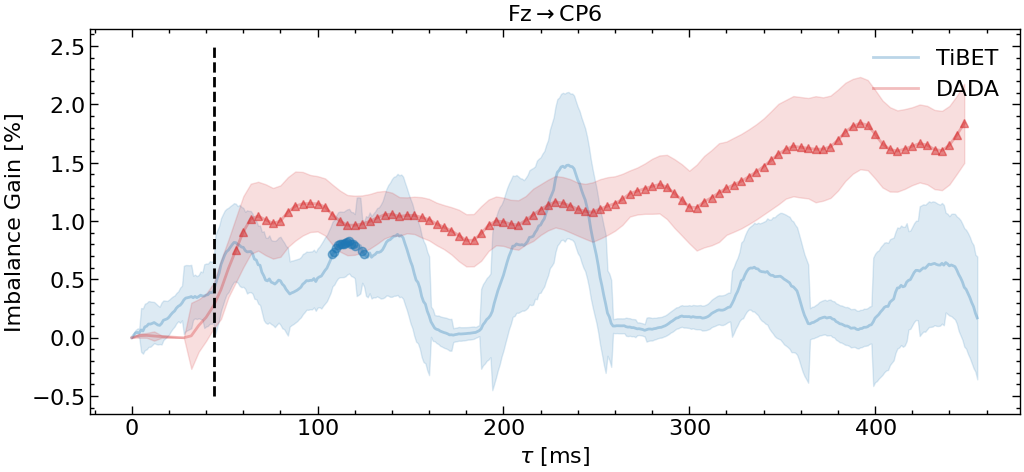

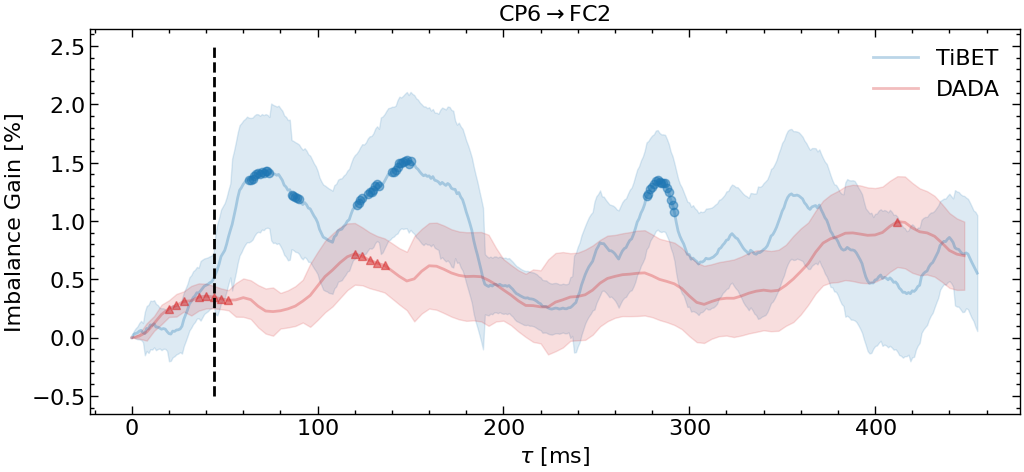

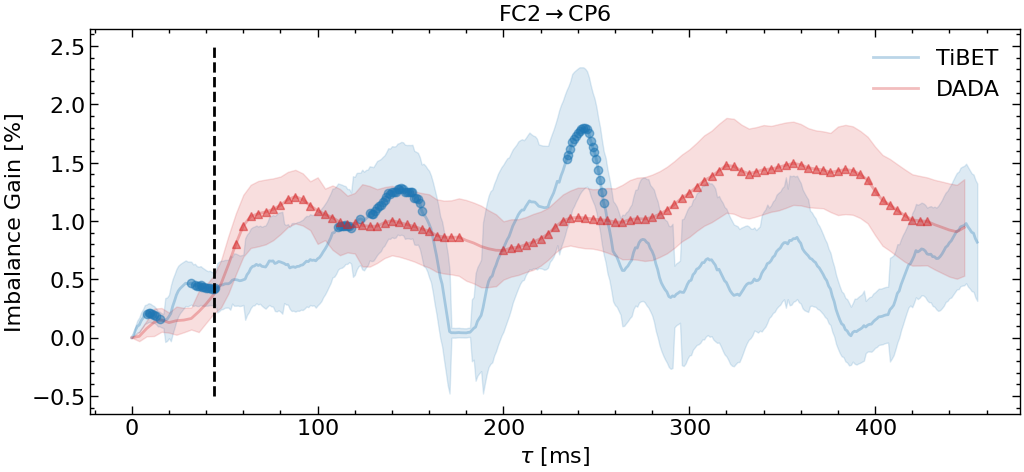

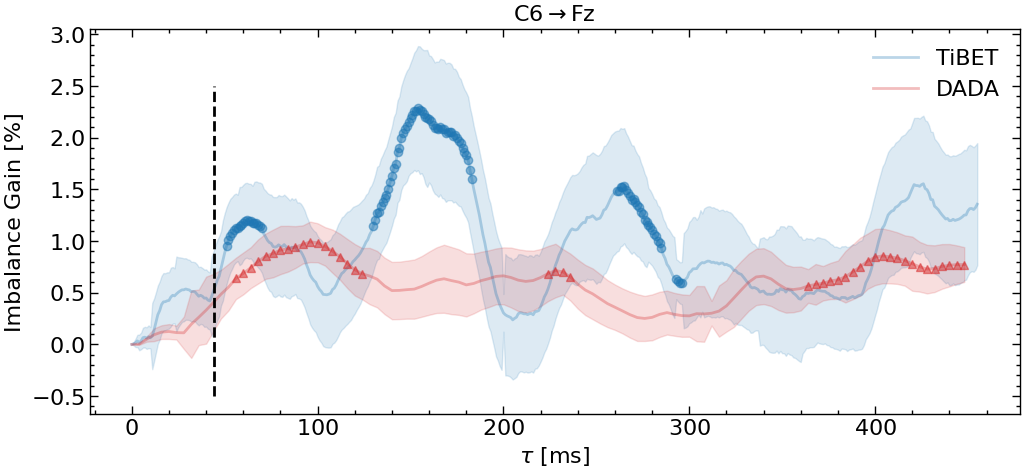

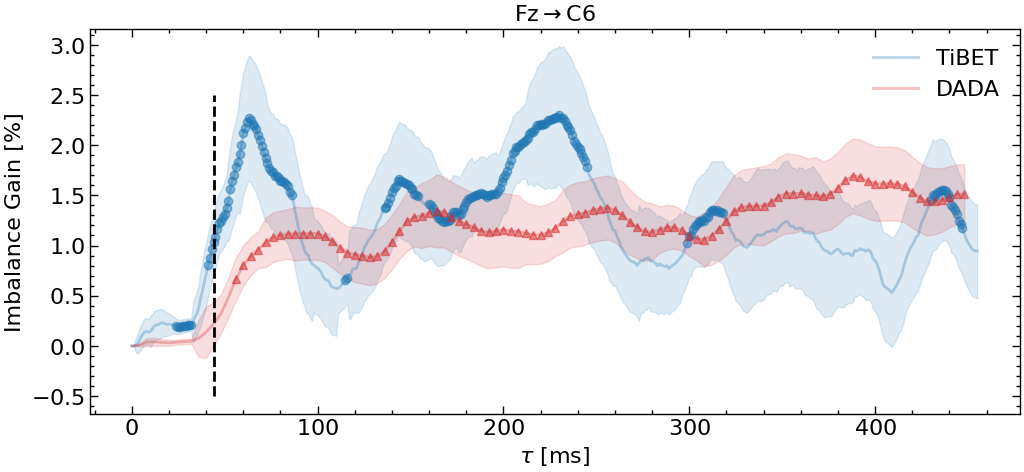

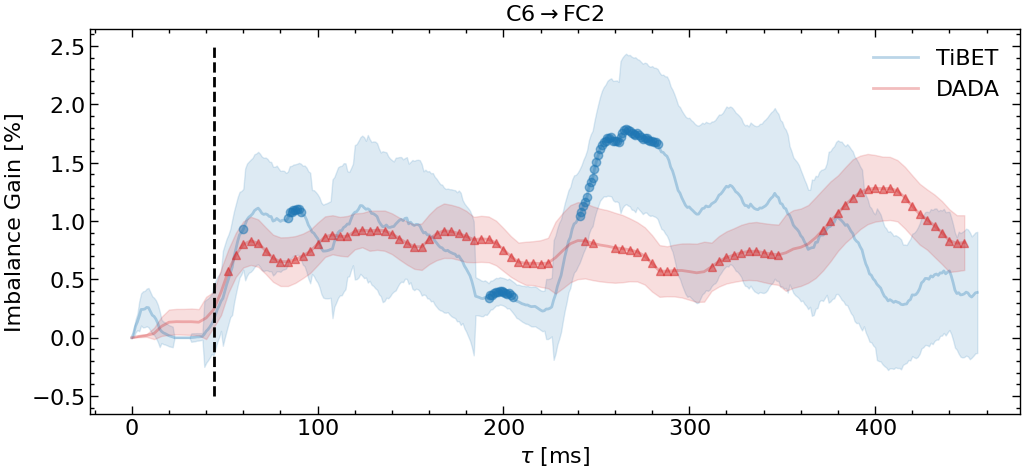

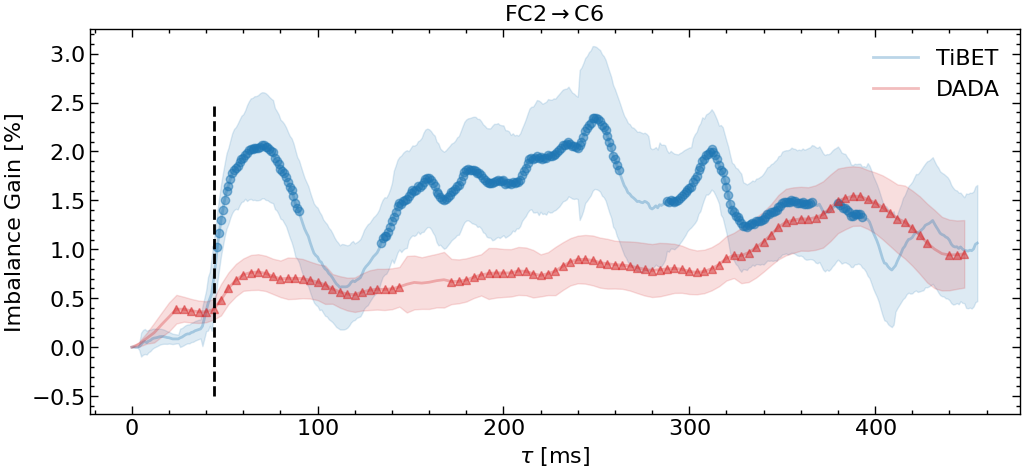

In [24]:
# plot results as a function of tau
for channel_X in channels_X:
    for channel_Y in channels_Y:

        ################################################# X -> Y #################################################
        fig, ax = plt.subplots(1,1,figsize=(12,5))
        ax.plot(taus_tibet, IGs_X_to_Y["tibet",channel_X,channel_Y], '-', label=f"TiBET", color="tab:blue", alpha=0.3)
        ax.plot(taus_dada, IGs_X_to_Y["dada",channel_X,channel_Y], '-', label=f"DADA", color="tab:red", alpha=0.3)

        mask_tibet = (IGs_X_to_Y["tibet",channel_X,channel_Y] / errors_X_to_Y["tibet",channel_X,channel_Y]) > t_20dof_99
        mask_dada = (IGs_X_to_Y["dada",channel_X,channel_Y] / errors_X_to_Y["dada",channel_X,channel_Y]) > t_18dof_99

        ax.plot(taus_tibet[mask_tibet], IGs_X_to_Y["tibet",channel_X,channel_Y][mask_tibet], 'o', color="tab:blue", alpha=0.5)
        ax.plot(taus_dada[mask_dada], IGs_X_to_Y["dada",channel_X,channel_Y][mask_dada], '^', color="tab:red", alpha=0.5)

        ax.fill_between(taus_tibet, IGs_X_to_Y["tibet",channel_X,channel_Y]-errors_X_to_Y["tibet",channel_X,channel_Y], 
                        IGs_X_to_Y["tibet",channel_X,channel_Y]+errors_X_to_Y["tibet",channel_X,channel_Y], color="tab:blue", alpha=0.15)
        ax.fill_between(taus_dada, IGs_X_to_Y["dada",channel_X,channel_Y]-errors_X_to_Y["dada",channel_X,channel_Y], 
                        IGs_X_to_Y["dada",channel_X,channel_Y]+errors_X_to_Y["dada",channel_X,channel_Y], color="tab:red", alpha=0.15)
        
        ax.vlines(E_tibet-1,-0.5,2.5, linestyle="--", color="black")
        ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]", title=f"{channel_X}$\\rightarrow ${channel_Y}")
        ax.legend()#loc="upper center")
        plt.savefig(f"./figures/IG_channel{channel_X}_to_channel{channel_Y}.pdf", dpi=300)
        plt.show()

        ################################################# Y -> X #################################################
        fig, ax = plt.subplots(1,1,figsize=(12,5))
        ax.plot(taus_tibet, IGs_Y_to_X["tibet",channel_X,channel_Y], '-', label=f"TiBET", color="tab:blue", alpha=0.3)
        ax.plot(taus_dada, IGs_Y_to_X["dada",channel_X,channel_Y], '-', label=f"DADA", color="tab:red", alpha=0.3)

        mask_tibet = (IGs_Y_to_X["tibet",channel_X,channel_Y] / errors_Y_to_X["tibet",channel_X,channel_Y]) > t_20dof_99
        mask_dada = (IGs_Y_to_X["dada",channel_X,channel_Y] / errors_Y_to_X["dada",channel_X,channel_Y]) > t_18dof_99

        ax.plot(taus_tibet[mask_tibet], IGs_Y_to_X["tibet",channel_X,channel_Y][mask_tibet], 'o', color="tab:blue", alpha=0.5)
        ax.plot(taus_dada[mask_dada], IGs_Y_to_X["dada",channel_X,channel_Y][mask_dada], '^', color="tab:red", alpha=0.5)

        ax.fill_between(taus_tibet, IGs_Y_to_X["tibet",channel_X,channel_Y]-errors_Y_to_X["tibet",channel_X,channel_Y], 
                        IGs_Y_to_X["tibet",channel_X,channel_Y]+errors_Y_to_X["tibet",channel_X,channel_Y], color="tab:blue", alpha=0.15)
        ax.fill_between(taus_dada, IGs_Y_to_X["dada",channel_X,channel_Y]-errors_Y_to_X["dada",channel_X,channel_Y], 
                        IGs_Y_to_X["dada",channel_X,channel_Y]+errors_Y_to_X["dada",channel_X,channel_Y], color="tab:red", alpha=0.15)
        
        ax.vlines(E_tibet-1,-0.5,2.5, linestyle="--", color="black")
        ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]", title=f"{channel_Y}$\\rightarrow ${channel_X}")
        ax.legend()#loc="upper center")
        plt.savefig(f"./figures/IG_channel{channel_Y}_to_channel{channel_X}.pdf", dpi=300)
        plt.show()